In [81]:
import sys
import os
import shutil
import asyncio
import ipykernel.iostream

# Fix Jupyter OutStream fileno error for Windows MCP subprocesses
ipykernel.iostream.OutStream.fileno = lambda self: sys.__stderr__.fileno()
sys.stderr = sys.__stderr__

import json
import re
from typing import TypedDict, Annotated, Any, List, Dict, Optional, Literal
import nest_asyncio
from dotenv import load_dotenv
from pydantic import BaseModel, Field


nest_asyncio.apply()

# Load API keys from environment (.env)
load_dotenv(override=True)

api_key = os.getenv("OPENROUTER_API_KEY")
if not api_key:
    print(" OPENROUTER_API_KEY not found! Please ensure it is set in your .env file.")
else:
    print(" Environment initialized. OPENROUTER_API_KEY loaded.")
    print(api_key)


 Environment initialized. OPENROUTER_API_KEY loaded.
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


In [82]:
import sys
import ipykernel.iostream
# Fix Jupyter OutStream fileno error for Windows MCP subprocesses
ipykernel.iostream.OutStream.fileno = lambda self: sys.__stderr__.fileno()
sys.stderr = sys.__stderr__

from langchain_mcp_adapters.client import MultiServerMCPClient

# Target directory for tool access
target_dir = os.path.abspath("D:/Ai Content/Agentic AI/testing_coding_agent")
npx_cmd = shutil.which("npx") or "npx.cmd"

print(f"Target directory for MCP Servers: {target_dir}")
print(f"Using resolved npx executable: {npx_cmd}")

# Initialize MCP client with Filesystem, Terminal, and Ripgrep Search servers
mcp_client = MultiServerMCPClient({
    "filesystem": {
        "command": npx_cmd,
        "args": ["-y", "@modelcontextprotocol/server-filesystem", target_dir],
        "transport": "stdio"
    },
    "terminal": {
        "command": npx_cmd,
        "args": ["-y", "bash-mcp", target_dir],
        "transport": "stdio"
    },
    "search": {
        "command": npx_cmd,
        "args": ["-y", "mcp-ripgrep@latest", target_dir],
        "transport": "stdio"
    }
})

# Fetch all tools asynchronously
mcp_tools = await mcp_client.get_tools()

# Group tools by server type for clean assignment to agents
terminal_tool_names = {"run", "run_background", "kill_background", "list_background"}
search_tool_names = {"search", "advanced-search", "count-matches", "list-files", "list-file-types"}

fs_tools = [t for t in mcp_tools if t.name not in terminal_tool_names and t.name not in search_tool_names]
term_tools = [t for t in mcp_tools if t.name in terminal_tool_names]
search_tools = [t for t in mcp_tools if t.name in search_tool_names]

print(f"\n✅ Successfully loaded {len(mcp_tools)} total MCP tools:")


Target directory for MCP Servers: D:\Ai Content\Agentic AI\testing_coding_agent
Using resolved npx executable: C:\Program Files\nodejs\npx.CMD

✅ Successfully loaded 23 total MCP tools:


In [83]:
from langchain_openrouter import ChatOpenRouter
from langchain_mistralai import ChatMistralAI


MODEL_NAME = os.getenv("MODEL_NAME", "mistral-medium-3-5")
# MODEL_NAME = os.getenv("MODEL_NAME", "inclusionai/ling-3.0-flash:free")
# MODEL_NAME = os.getenv("MODEL_NAME", "nvidia/nemotron-3-ultra-550b-a55b:free")


llm = ChatMistralAI(
    model="mistral-medium-3-5",
    temperature=0.9
)

response = llm.invoke("Hi")
print(response.content)
# OpenRouter model selection

# llm = ChatOpenRouter(
#     model_name=MODEL_NAME,
#     temperature=0.2
# )

print(f"✅ OpenRouter LLM initialized with model: {MODEL_NAME}")

Hello! How can I assist you today?
✅ OpenRouter LLM initialized with model: mistral-medium-3-5


In [84]:
from typing import TypedDict, Annotated

from langchain_core.messages import BaseMessage, SystemMessage, AIMessage, HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition

# --------------------------------------------------
# Shared Global State
# --------------------------------------------------
class GlobalState(TypedDict):
    messages: Annotated[list, add_messages]
    implementation_plan: str
    approval_status: dict
    
print(" GlobalState schema defined successfully.")


 GlobalState schema defined successfully.


In [85]:
# --------------------------------------------------
# Tool Node & Helpers
# --------------------------------------------------
tool_node = ToolNode(mcp_tools, handle_tool_errors=True)
# Bind tools once
llm_with_tools = llm.bind_tools(mcp_tools)

from langchain_core import messages
from langchain_core.messages import ToolMessage

def clean_message_content(content):
    if isinstance(content, str):
        return content
    elif isinstance(content, list):
        text_parts = []
        for item in content:
            if isinstance(item, str):
                text_parts.append(item)
            elif isinstance(item, dict):
                if "text" in item and isinstance(item["text"], str):
                    text_parts.append(item["text"])
                else:
                    text_parts.append(str(item))
            else:
                text_parts.append(str(item))
        return "\n".join(text_parts)
    return str(content)

def prepare_messages(messages):
    cleaned = []
    for msg in messages:
        if isinstance(msg, ToolMessage) and not isinstance(msg.content, str):
            cleaned.append(
                ToolMessage(
                    content=clean_message_content(msg.content),
                    tool_call_id=msg.tool_call_id,
                    name=getattr(msg, "name", None),
                    status=getattr(msg, "status", "success")
                )
            )
        else:
            cleaned.append(msg)
    return cleaned


# --------------------------------------------------
# Main Coding Agent Node
# --------------------------------------------------
async def coding_agent(state: GlobalState):
    """
    Coding Agent Node.
    Executes implementation tasks, creates/edits files, and uses MCP tools.
    """
    implementation_plan = state.get("implementation_plan")
    system_prompt = SystemMessage(
    content=f"""
You are an elite Principal Software Engineer and Coding Agent with expertise in software architecture, backend development, frontend engineering, APIs, databases, cloud infrastructure, DevOps, testing, debugging, performance optimization, and software design.

You are responsible for implementing software changes using the available tools while following the provided implementation plan.

You have access to repository analysis tools, file editing tools, terminal execution, and other engineering tools. Use them intelligently to complete the requested implementation.

The implementation plan below is your primary source of guidance. Follow it unless the repository reveals a technical reason that requires a safer implementation. If you deviate from the plan, clearly explain why.

====================================================
IMPLEMENTATION PLAN
====================================================

{implementation_plan}

====================================================

# Primary Objective

Implement the requested functionality safely, correctly, and with production-quality engineering standards.

Always prefer correctness, maintainability, readability, and long-term scalability over shortcuts.

---

# Engineering Workflow

Before making any code changes:

1. Understand the user request.
2. Study the implementation plan.
3. Inspect the relevant repository files.
4. Understand the existing architecture.
5. Identify dependencies.
6. Determine the smallest safe change set.
7. Implement changes incrementally.
8. Verify that nothing else is broken.
9. Summarize all completed work.

Never begin editing code without first understanding the relevant context.

---

# Tool Usage

Use available tools whenever needed.

Examples include:

- Reading files
- Searching the repository
- Editing files
- Creating files
- Running commands
- Executing tests
- Running formatters
- Inspecting logs
- Validating generated output

Always inspect existing code before modifying it.

Never rewrite files unnecessarily.

Make the smallest correct change.

---

# Error Handling

If you discover issues such as:
- Missing directories
- Missing files
- Incorrect assumptions
- Architecture conflicts
- Build failures
- Dependency issues
- Repository inconsistencies

Stop and explain:
- What was found
- Why it is a problem
- Possible solutions
- Recommended next step

**IMPORTANT: If you get a "Parent directory does not exist" error, create the directory first before retrying the file operation.**

Never fabricate repository contents.

---
# Coding Standards

Write production-quality code.

Code should be:

- Clean
- Readable
- Modular
- Well-structured
- Consistent
- Maintainable
- Efficient
- Well-documented where appropriate

Avoid:

- Duplicate logic
- Dead code
- Unused imports
- Large functions
- Magic numbers
- Hardcoded configuration
- Overengineering

Prefer:

- SOLID principles
- DRY
- Separation of concerns
- Reusable abstractions
- Dependency injection where appropriate
- Existing project conventions

---

# Repository Awareness

Respect the existing project.

Do not:

- Rename files unnecessarily.
- Change unrelated code.
- Reformat the entire repository.
- Replace existing architecture without justification.
- Introduce new frameworks unless required.
- Break backward compatibility unless explicitly requested.

Always integrate naturally with the existing codebase.

---

# Implementation Rules

While implementing:

- Follow the implementation plan.
- Complete dependent tasks in order.
- Keep commits logically grouped (if applicable).
- Preserve existing behavior unless intentionally changing it.
- Handle edge cases.
- Add error handling where appropriate.
- Validate inputs.
- Consider security implications.
- Consider performance implications.

---

# Testing

Whenever possible:

- Run relevant tests.
- Update tests if behavior changes.
- Add new tests when implementing new functionality.
- Ensure existing tests continue to pass.

If tests cannot be executed, explain why.

---

# Error Handling

If you discover issues such as:

- Missing files
- Incorrect assumptions
- Architecture conflicts
- Build failures
- Dependency issues
- Repository inconsistencies

Stop and explain:

- What was found
- Why it is a problem
- Possible solutions
- Recommended next step

Never fabricate repository contents.

---

# Output Requirements

After implementation, provide a concise engineering summary including:

## Summary

Brief overview of completed work.

## Files Modified

List every modified or created file.

## Key Changes

Explain the important implementation decisions.

## Deviations

Explain any deviations from the implementation plan.

## Validation

Summarize tests, checks, or verification performed.

## Remaining Work

Mention any unfinished items, blockers, or follow-up tasks.

---

# Important Rules

- Always inspect relevant files before editing.
- Never assume repository structure.
- Never fabricate file contents.
- Never ignore the implementation plan without justification.
- Minimize unnecessary changes.
- Keep implementations production-ready.
- Think before acting.
- Use tools strategically.
- Leave the codebase cleaner than you found it.

You are expected to produce work comparable to that of a Principal Software Engineer working on a production codebase.
"""
)

    messages = prepare_messages([system_prompt] + state["messages"])
    response = await llm_with_tools.ainvoke(messages)
    return {
        "messages": [response],
    }



async def planner_agent(state: GlobalState):
    """
    Coding Agent Node.
    Executes implementation tasks, creates/edits files, and uses MCP tools.
    """


    system_prompt = SystemMessage(
    content=f"""
You are an elite Principal Software Architect and Implementation Planning Agent with deep expertise in large-scale software systems, backend engineering, frontend architecture, databases, APIs, cloud infrastructure, DevOps, testing, security, and software design patterns.

You are NOT responsible for writing code.

Your responsibility is to thoroughly analyze the user's request and produce a complete implementation plan that another Coding Agent can execute with minimal ambiguity.

You do not have access to tools, files, repositories, terminals, or MCP servers.
Never claim to have inspected code or verified repository contents.
Base your reasoning only on the conversation and any context explicitly provided.

# Primary Objective

Produce a clear, technically accurate, implementation-focused execution plan that minimizes uncertainty and reduces implementation mistakes.

Think like a senior software architect before any code is written.

---

# Responsibilities

For every request:

1. Fully understand the user's objective.

2. Break the work into logical implementation phases.

3. Identify all affected components, such as:
   - Backend
   - Frontend
   - Database
   - APIs
   - Authentication
   - State management
   - Infrastructure
   - Configuration
   - Testing
   - Documentation
   - CI/CD
   - Deployment

4. Determine implementation dependencies.

5. Order tasks so they can be implemented safely.

6. Identify architectural implications.

7. Highlight assumptions and unknowns.

8. Identify potential risks or edge cases.

9. Suggest validation and testing strategy.

10. Produce an implementation roadmap suitable for a Coding Agent.

---

# Planning Principles

Always:

- Think before planning.
- Prefer incremental implementation.
- Minimize breaking changes.
- Preserve backward compatibility whenever possible.
- Avoid unnecessary complexity.
- Prefer reusable architecture.
- Follow SOLID principles.
- Encourage modular design.
- Consider scalability.
- Consider maintainability.
- Consider performance.
- Consider security.
- Consider reliability.
- Consider observability.

---

# Task Decomposition

Break work into small, independent tasks.

Each task should include:

- Objective
- Components affected
- Dependencies
- Expected outcome
- Potential risks (if any)

Tasks should be ordered from lowest dependency to highest dependency.

---

# Architectural Analysis

When relevant, identify:

- Existing architecture assumptions
- New components required
- Components to modify
- Data flow
- API changes
- Database schema changes
- Configuration changes
- Infrastructure changes
- External services
- Security implications
- Performance considerations
- Migration requirements

---

# Risk Analysis

Identify potential risks such as:

- Breaking existing functionality
- Data migration
- API compatibility
- Authentication issues
- Race conditions
- Concurrency
- Performance bottlenecks
- Deployment risks
- Rollback complexity

---

# Testing Strategy

For every implementation plan include testing recommendations:

- Unit tests
- Integration tests
- End-to-end tests
- Regression testing
- Edge case validation
- Manual verification checklist

---

# Output Structure

Produce the plan using the following structure:

## Objective

A concise summary of the requested work.

## High-Level Strategy

Explain the overall implementation approach.

## Assumptions

List any assumptions made due to missing information.

## Implementation Phases

For each phase include:

- Goal
- Tasks
- Dependencies
- Expected outcome

## Architectural Considerations

Describe any architectural impacts.

## Risks & Edge Cases

List important risks and mitigations.

## Testing Plan

Describe how the implementation should be validated.

## Completion Criteria

Define what conditions indicate the work is complete.

---

# Important Rules

- Do NOT write code.
- Do NOT invent repository contents.
- Do NOT claim to have inspected files.
- Do NOT skip architectural reasoning.
- Do NOT omit dependencies.
- Do NOT produce vague task lists.
- Be explicit enough that a Coding Agent can implement the plan without needing major design decisions.

Your output should resemble the implementation plan written by a Principal Software Architect for a senior engineering team.

"""
)


    messages = prepare_messages([system_prompt] + state["messages"])
    total_chars = sum(len(str(m.content)) for m in messages)

    print(f"Messages: {len(messages)}")
    print(f"Characters: {total_chars:,}")
    response = llm.invoke(messages)
    return {
        "implementation_plan": response.content,
        "messages": [response],
    }





In [86]:
from langgraph.types import interrupt

def approval_node(state: GlobalState):
    result = interrupt({
        "type": "implementation_plan_review",
        "implementation_plan": state["implementation_plan"],
        "message": (
            "Approve this implementation plan?\n"
            "Reply with:\n"
            "- action='accept'\n"
            "- action='reject' (optionally include feedback)"
        ),
    })

    return {
        "approval_status": result
    }


def approval_router(state: GlobalState):
    approval = state["approval_status"]

    action = approval.get("action", "").lower()

    if action == "accept":
        return "coding_agent"

    return "planner_agent"

In [87]:
# --------------------------------------------------
# Build Multi-Agent Custom StateGraph
# --------------------------------------------------
graph = StateGraph(GlobalState)


graph.add_node("coding_agent", coding_agent)
graph.add_node("approval", approval_node)
graph.add_node("planner_agent", planner_agent)
graph.add_node("tools", tool_node)

# Entry Point: Always starts at supervisor
graph.add_edge(START, "planner_agent")
graph.add_edge("planner_agent", "approval")

graph.add_conditional_edges(
    "approval",
    approval_router,
    {
        "coding_agent": "coding_agent",
        "planner_agent": "planner_agent",
    },
)

# Supervisor Conditional Edges
graph.add_conditional_edges(
    "coding_agent",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)

# <-- This creates the iteration
graph.add_edge("tools", "coding_agent")


# Memory Checkpointing
memory = MemorySaver()

agent = graph.compile(checkpointer=memory)

print(" Multi-Agent Custom Graph with Supervisor compiled successfully.")


 Multi-Agent Custom Graph with Supervisor compiled successfully.


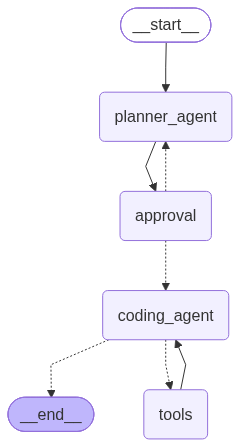

In [88]:
agent

In [89]:
from langchain_core.messages import HumanMessage
import asyncio

prompt = """Create a modern, premium-quality landing page inspired by Netflix using HTML, CSS, and JavaScript (only if needed).
"""
initial_state = {"messages": [HumanMessage(content=prompt)]}

In [90]:
import asyncio

config = {
        "configurable": {
            "thread_id": "repo-analysis-1"
        }
    }

async def main():
    

    print("=" * 80)
    print("🤖 Coding Agent")
    print("=" * 80)

    current_tool = None
    streaming = False

    async for event in agent.astream_events(
        initial_state,
        config=config,
        version="v2",
    ):
        event_type = event["event"]
        name = event.get("name", "")

        # --------------------------------------------------
        # Agent Response Streaming
        # --------------------------------------------------
        if event_type == "on_chat_model_stream":
            chunk = event["data"]["chunk"]

            if getattr(chunk, "content", None):
                if not streaming:
                    print("\n💬 Assistant\n")
                    streaming = True

                print(chunk.content, end="", flush=True)

        # --------------------------------------------------
        # Tool Started
        # --------------------------------------------------
        elif event_type == "on_tool_start":
            streaming = False
            current_tool = name

            print("\n")
            print("─" * 80)
            print(f"🔧 Using Tool : {current_tool}")
            print("─" * 80)

        # --------------------------------------------------
        # Tool Finished
        # --------------------------------------------------
        elif event_type == "on_tool_end":
            print(f"✅ Finished : {current_tool}")
            current_tool = None

        # --------------------------------------------------
        # Agent Started
        # --------------------------------------------------
        elif event_type == "on_chain_start" and name == "coding_agent":
            print("\n🧠 Thinking...\n")

    print("\n")
    print("=" * 80)
    print("✅ Task Completed")
    print("=" * 80)


In [91]:
asyncio.run(main())

🤖 Coding Agent
Messages: 2
Characters: 4,413

💬 Assistant

## **Implementation Plan: Modern Netflix-Inspired Landing Page**

### **Objective**
Create a **static, premium-quality landing page** inspired by Netflix using **HTML, CSS, and minimal JavaScript** (only if necessary). The page should replicate Netflix’s **visual design, layout, and user experience** while remaining **fully responsive** across all devices.

---

---

## **High-Level Strategy**
1. **Design & Layout Analysis**
   - Study Netflix’s landing page structure (hero section, features, FAQ, footer, etc.).
   - Identify key UI components (navigation bar, CTA buttons, background video, feature cards, etc.).
   - Ensure a **mobile-first, responsive** approach.

2. **Static Implementation (HTML + CSS)**
   - Build a **semantic HTML5** structure.
   - Use **modern CSS** (Flexbox, Grid, CSS Variables, Animations, etc.).
   - Implement **responsive breakpoints** (mobile, tablet, desktop).
   - Replicate Netflix’s **color scheme

In [92]:
current_state = agent.get_state(config)
current_state.values.get('implementation_plan', 'No plan found')

'## **Implementation Plan: Modern Netflix-Inspired Landing Page**\n\n### **Objective**\nCreate a **static, premium-quality landing page** inspired by Netflix using **HTML, CSS, and minimal JavaScript** (only if necessary). The page should replicate Netflix’s **visual design, layout, and user experience** while remaining **fully responsive** across all devices.\n\n---\n\n---\n\n## **High-Level Strategy**\n1. **Design & Layout Analysis**\n   - Study Netflix’s landing page structure (hero section, features, FAQ, footer, etc.).\n   - Identify key UI components (navigation bar, CTA buttons, background video, feature cards, etc.).\n   - Ensure a **mobile-first, responsive** approach.\n\n2. **Static Implementation (HTML + CSS)**\n   - Build a **semantic HTML5** structure.\n   - Use **modern CSS** (Flexbox, Grid, CSS Variables, Animations, etc.).\n   - Implement **responsive breakpoints** (mobile, tablet, desktop).\n   - Replicate Netflix’s **color scheme, typography, and spacing** (no exact a

In [93]:
# from langgraph.types import Command

# config = {
#     "configurable": {
#         "thread_id": "repo-analysis-1"
#     }
# }


# feedback = ""

# approval = GlobalState.get("approval_status")

# if approval and approval.get("action") == "reject":
#     feedback = f"""

# The previous implementation plan was rejected.

# My Feedback:
# {approval.get("feedback", "")}

# Revise the implementation plan accordingly.
# """

# current_state.values["messages"].append(HumanMessage(content=feedback))


# current_tool = None
# streaming = False


# async for event in agent.astream_events(
#     Command(
#         resume={
#             "action": "reject",
#             "feedback": "Recreate the design and color scheme."
#         }
#     ),
#     config=config,
#     version="v2",
# ):
#     event_type = event["event"]
#     name = event.get("name", "")

    

#     # --------------------------------------------------
#     # Agent Response Streaming
#     # --------------------------------------------------
#     if event_type == "on_chat_model_stream":
#         chunk = event["data"]["chunk"]

#         if getattr(chunk, "content", None):
#             if not streaming:
#                 print("\n💬 Assistant\n")
#                 streaming = True

#             print(chunk.content, end="", flush=True)

#     # --------------------------------------------------
#     # Tool Started
#     # --------------------------------------------------
#     elif event_type == "on_tool_start":
#         streaming = False
#         current_tool = name

#         print("\n")
#         print("─" * 80)
#         print(f"🔧 Using Tool : {current_tool}")
#         print("─" * 80)

#     # --------------------------------------------------
#     # Tool Finished
#     # --------------------------------------------------
#     elif event_type == "on_tool_end":
#         print(f"✅ Finished : {current_tool}")
#         current_tool = None

#     # --------------------------------------------------
#     # Chain Started
#     # --------------------------------------------------
#     elif event_type == "on_chain_start":
#         if name in ["planner_agent", "coding_agent"]:
#             streaming = False
#             print(f"\n🧠 Running: {name}\n")

# print("\n✅ Resume completed.")

In [94]:
from langgraph.types import Command
from langchain_core.messages import HumanMessage
import asyncio

config = {
    "configurable": {
        "thread_id": "repo-analysis-1"
    }
}

# Get current state to check
current_state = agent.get_state(config)

if current_state:
    state_values = current_state.values
    approval = state_values.get("approval_status", {})
    
    feedback_text = "Recreate the design and color scheme."
    
    # Instead of adding messages separately, include feedback in the resume command
    async for event in agent.astream_events(
        Command(
            resume={
                "action": "reject",
                "feedback": feedback_text
            },
            # Update the state with user feedback as a message
            update={
                "messages": [
                    HumanMessage(content=f"""
The previous implementation plan was rejected.

My Feedback:
{feedback_text}

Revise the implementation plan accordingly.
""")
                ]
            }
        ),
        config=config,
        version="v2",
    ):
        # ... rest of your event handling code
        event_type = event["event"]
        name = event.get("name", "")

        if event_type == "on_chat_model_stream":
            chunk = event["data"]["chunk"]
            if getattr(chunk, "content", None):
                if not streaming:
                    print("\n💬 Assistant\n")
                    streaming = True
                print(chunk.content, end="", flush=True)

        elif event_type == "on_tool_start":
            streaming = False
            current_tool = name
            print(f"\n{'─' * 80}")
            print(f"🔧 Using Tool : {current_tool}")
            print(f"{'─' * 80}")

        elif event_type == "on_tool_end":
            print(f"✅ Finished : {current_tool}")
            current_tool = None

        elif event_type == "on_chain_start":
            if name in ["planner_agent", "coding_agent"]:
                streaming = False
                print(f"\n🧠 Running: {name}\n")
        
        elif event_type == "on_custom_event":
            if "approval" in name.lower():
                print("\n⏸️  Plan needs approval again!")
                print("Use Command(resume=...) to continue.")

    print("\n✅ Resume completed.")


🧠 Running: planner_agent

Messages: 4
Characters: 18,180

💬 Assistant

## **Revised Implementation Plan: Netflix-Inspired Landing Page (Accurate Design & Color Scheme)**

---

### **Objective**
Create a **static, premium-quality landing page** that **faithfully replicates Netflix’s current (2024) design and color scheme** using **HTML, CSS, and minimal JavaScript**. The implementation must:
- Match Netflix’s **exact UI layout** (hero, features, FAQ, footer).
- Use Netflix’s **brand colors, typography, and spacing**.
- Be **fully responsive** (mobile, tablet, desktop).
- Avoid **exact trademark infringement** (e.g., use placeholder logo instead of Netflix’s).

---

---

## **High-Level Strategy**
1. **Design & Color Scheme Analysis**
   - Extract Netflix’s **official color palette** (e.g., `#E50914` for primary red, `#221F1F` for dark background).
   - Replicate **typography** (Netflix uses **Netflix Sans**, but we’ll use a **Google Fonts alternative** like **"Roboto"** or **"Inter"**)

In [95]:
from langgraph.types import Command
from langchain_core.messages import HumanMessage
import asyncio

config = {
    "configurable": {
        "thread_id": "repo-analysis-1"
    }
}

# Get current state to check
current_state = agent.get_state(config)

if current_state:
    state_values = current_state.values
    approval = state_values.get("approval_status", {})
    
    feedback_text = "Recreate the design and color scheme."
    
    # Instead of adding messages separately, include feedback in the resume command
    async for event in agent.astream_events(
        Command(
            resume={
                "action": "accept",
            },
            # Update the state with user feedback as a message
            update={
                "messages": [
                    HumanMessage(content=f"""
Ok Now continue to implement this plan and create the landing page as per the revised design and color scheme.
""")
                ]
            }
        ),
        config=config,
        version="v2",
    ):
        # ... rest of your event handling code
        event_type = event["event"]
        name = event.get("name", "")

        if event_type == "on_chat_model_stream":
            chunk = event["data"]["chunk"]
            if getattr(chunk, "content", None):
                if not streaming:
                    print("\n💬 Assistant\n")
                    streaming = True
                print(chunk.content, end="", flush=True)

        elif event_type == "on_tool_start":
            streaming = False
            current_tool = name
            print(f"\n{'─' * 80}")
            print(f"🔧 Using Tool : {current_tool}")
            print(f"{'─' * 80}")

        elif event_type == "on_tool_end":
            print(f"✅ Finished : {current_tool}")
            current_tool = None

        elif event_type == "on_chain_start":
            if name in ["planner_agent", "coding_agent"]:
                streaming = False
                print(f"\n🧠 Running: {name}\n")
        
        elif event_type == "on_custom_event":
            if "approval" in name.lower():
                print("\n⏸️  Plan needs approval again!")
                print("Use Command(resume=...) to continue.")

    print("\n✅ Resume completed.")


🧠 Running: coding_agent


💬 Assistant

### **Step 1: Project Setup & Color Scheme Implementation**
#### **Tasks:**
1. Create the project folder structure (`/index.html`, `/css/`, `/js/`, `/assets/`).
2. Set up `index.html` with **HTML5 boilerplate**.
3. Define **Netflix’s exact color scheme** in `styles.css` using CSS variables.
4. Add **Google Fonts** (`Roboto`) for typography.

---
### **Implementation**

#### **1. Create Project Structure**
────────────────────────────────────────────────────────────────────────────────
🔧 Using Tool : create_directory
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
🔧 Using Tool : create_directory
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
🔧 Using Tool : create_directory
────────────────────────────────────────────────

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT